In [127]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, draw

krok = 0.5
detektory = 240
rozpietosc_katowa = 180
nazwaPliku = "obrazy/SADDLE_PE.jpg"

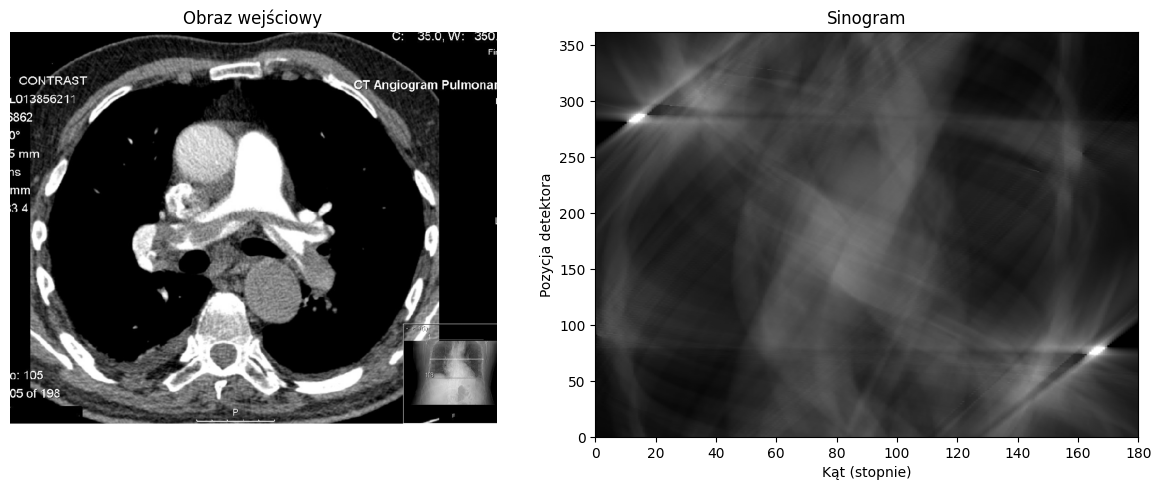

In [128]:

def blad_sredniokwadratowy(obraz_wej, obraz_wyj):
    obraz_wej = obraz_wej.astype(np.float64)
    obraz_wyj = obraz_wyj.astype(np.float64)

    return np.mean((obraz_wej - obraz_wyj) ** 2)

def transformataRadona(obraz, krok, detektory, rozpietosc):
    h, w = obraz.shape
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    sinogram = []
    while theta <= 180:
        row = []
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)

        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2
        for i in range(detektory):
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)

            # pozycja detektora
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            # punkty na promieniu
            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))

            suma = 0
            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    suma += obraz[y, x]
            row.append(suma)

        sinogram.append(row)
        theta += krok
    return np.array(sinogram)

# ========================================================================================
image = io.imread(nazwaPliku)
if len(image.shape) == 3:
    image = color.rgb2gray(image)
image /= np.max(image)

sinogram = transformataRadona(image, krok, detektory, rozpietosc_katowa)
sinogram /= np.max(sinogram)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Obraz wejściowy")
ax[0].axis("off")

ax[1].imshow(sinogram, cmap='gray', aspect='auto', extent=(0, 180, 0, sinogram.shape[0]))

ax[1].set_title("Sinogram")
ax[1].set_xlabel("Kąt (stopnie)")
ax[1].set_ylabel("Pozycja detektora")

plt.tight_layout()
plt.show()

In [129]:
def kernel(n):
    h = np.zeros(n)
    center = n // 2

    for k in range(-center, center):
        if k == 0:
            h[center] = 1
        elif k % 2 != 0:
            h[center + k] = -4 / (np.pi**2 * k**2)
        else:
            h[center + k] = 0

    return h

def filtruj_sinogram(sinogram):
    filtr = kernel(21)
    wynik = np.zeros_like(sinogram)

    for i in range(sinogram.shape[0]):
        wynik[i] = np.convolve(sinogram[i], filtr, mode='same')

    return wynik

sinogram = filtruj_sinogram(sinogram)

Iteracja: 10 	MSE: 0.16574084454703727
Iteracja: 20 	MSE: 0.1592351621131423
Iteracja: 30 	MSE: 0.1537929359147275
Iteracja: 40 	MSE: 0.15110226146629196
Iteracja: 50 	MSE: 0.1435224630371358
Iteracja: 60 	MSE: 0.1353596579400333
Iteracja: 70 	MSE: 0.12814609391265694
Iteracja: 80 	MSE: 0.12837264579412364
Iteracja: 90 	MSE: 0.12289474683589956
Iteracja: 100 	MSE: 0.11970712375095084
Iteracja: 110 	MSE: 0.1163680600807008
Iteracja: 120 	MSE: 0.11372820387554404
Iteracja: 130 	MSE: 0.11175770944091463
Iteracja: 140 	MSE: 0.11037921791892062
Iteracja: 150 	MSE: 0.10814173110837133
Iteracja: 160 	MSE: 0.10513807633664862
Iteracja: 170 	MSE: 0.10369039045069688
Iteracja: 180 	MSE: 0.10440382810421443
Iteracja: 190 	MSE: 0.10177202754285318
Iteracja: 200 	MSE: 0.10134571359351968
Iteracja: 210 	MSE: 0.10312735617917408
Iteracja: 220 	MSE: 0.1082007169128959
Iteracja: 230 	MSE: 0.10699328194668085
Iteracja: 240 	MSE: 0.10503642722494497
Iteracja: 250 	MSE: 0.10328682840411452
Iteracja: 260 	

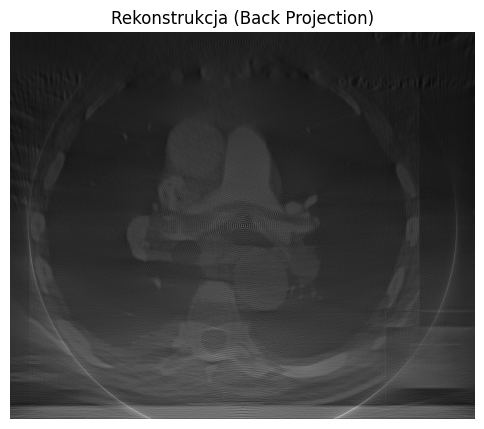

In [130]:
def odwrotnaTransformataRadona(sinogram, obraz_shape, krok, detektory, rozpietosc):
    h, w = obraz_shape
    rekonstrukcja = np.zeros((h, w))
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    j = 0
    while theta <= 180 and j < sinogram.shape[0]:
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)
        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2

        for i in range(detektory):
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))
            wartosc = sinogram[j][i] #/ len(punkty[0])

            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    rekonstrukcja[y, x] += wartosc

        theta += krok
        j += 1
        if j % 10 == 0:
            rek_norm = rekonstrukcja / np.max(rekonstrukcja)
            print("Iteracja:", j, "\tMSE:", blad_sredniokwadratowy(image, rek_norm))

    return rekonstrukcja

reconstructed = odwrotnaTransformataRadona(sinogram, image.shape, krok, detektory, rozpietosc_katowa)

plt.figure(figsize=(6,6))
plt.imshow(reconstructed, cmap='gray')
plt.title("Rekonstrukcja (Back Projection)")
plt.axis("off")
plt.show()